<h2>🚀 Intrusion Detection Model Training on CICIDS 2017 Dataset </h2>

<p>
This notebook demonstrates a comprehensive workflow on the <b>CICIDS2017 dataset</b>,
covering preprocessing, feature engineering, binary and multi-class model training, and deployment preparation.
</p>

<h3>Steps covered:</h3>
<ol>
  <li>Dataset loading and exploratory data analysis with class distribution visualization</li>
  <li>Data preprocessing: missing value handling, duplicate removal, and outlier detection</li>
  <li>Feature engineering: categorical encoding, normalization, and correlation analysis</li>
  <li>Binary classification: Normal vs Attack detection with SMOTE balancing</li>
  <li>Multi-class classification: Detailed attack type categorization (DoS variants, Heartbleed)</li>
  <li>Model training: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting</li>
  <li>Comprehensive evaluation: accuracy comparison, confusion matrices, and ROC-AUC analysis</li>
  <li>Performance visualization: bar plots, box plots, heatmaps, and cross-validation analysis</li>
  <li>Model comparison and selection based on multiple metrics (precision, recall, F1-score)</li>
  <li>Deployment preparation: model serialization and Streamlit application development</li>
</ol>

<h3>Step 1: Data Loading</h3>

In [91]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_curve, roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc


# Load dataset
file_path = '\infosys\cicids\Tuesday-WorkingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())


<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:21: SyntaxWarning: invalid escape sequence '\i'
C:\Users\C MOHAN RAAJ\AppData\Local\Temp\ipykernel_15752\3467129205.py:21: SyntaxWarning: invalid escape sequence '\i'
  file_path = '\infosys\cicids\Tuesday-WorkingHours.pcap_ISCX.csv'


Dataset shape: (445909, 79)

First 5 rows:
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 88             640                   7   
1                 88             900                   9   
2                 88            1205                   7   
3                 88             511                   7   
4                 88             773                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        4                          440   
1                        4                          600   
2                        4                         2776   
3                        4                          452   
4                        4                          612   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                           358                     220   
1                          2944                     300   
2                          2830                    1388   
3    

<h3>Step 2: Data Cleaning</h3>

In [92]:
# Check and drop missing values if any
print("Missing values in dataset:", df.isnull().sum().sum())
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print("Missing values dropped")

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {before - df.shape[0]} duplicates. New shape: {df.shape}")

Missing values in dataset: 201
Missing values dropped
Removed 24025 duplicates. New shape: (421683, 79)


<h3> Step 3: Target Label Creation and Distribution Plot</h3>

Class distribution:
attack_binary
0    412531
1      9152
Name: count, dtype: int64

Class distribution (%):
attack_binary
0    97.829649
1     2.170351
Name: proportion, dtype: float64


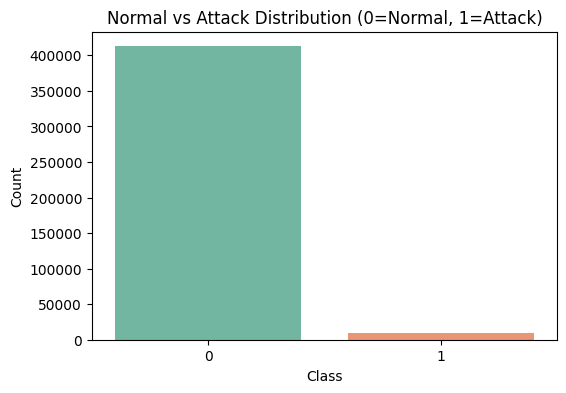

In [93]:
# Create binary target variable: 0 = Benign, 1 = Attack
df['attack_binary'] = df[' Label'].apply(lambda x: 0 if str(x).lower() == 'benign' else 1)

# Check class distribution
print("Class distribution:")
print(df['attack_binary'].value_counts())
print("\nClass distribution (%):")
print(df['attack_binary'].value_counts(normalize=True) * 100)

# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='attack_binary', data=df, hue='attack_binary', palette="Set2", legend=False)
plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

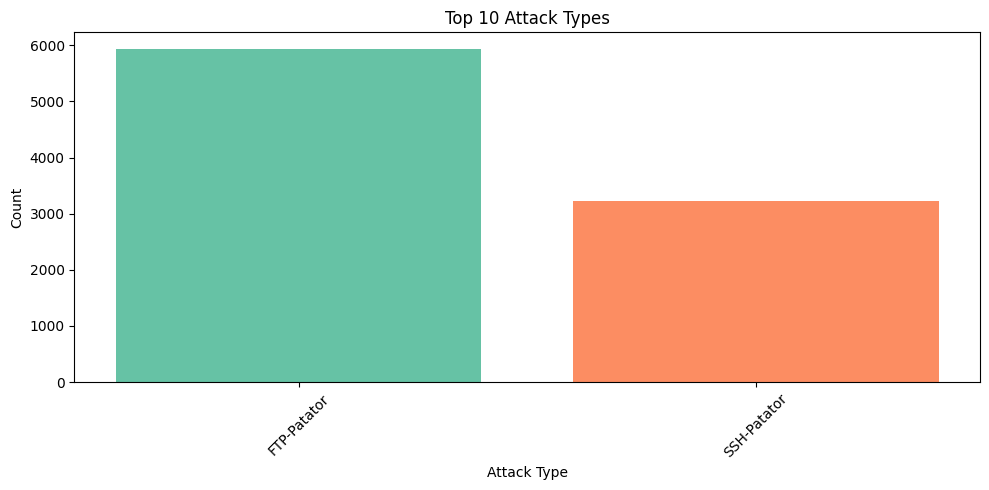

In [94]:
# Top 10 attack types plot
attack_counts = df[df[' Label'].str.lower() != 'benign'][' Label'].value_counts().head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(attack_counts.index, attack_counts.values)
colors = sns.color_palette("Set2", len(attack_counts))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title("Top 10 Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h3>Step 4: Feature Encoding</h3>

In [95]:
# Identify categorical columns except 'Label' and target
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in [' Label', 'attack_binary']]

print("Categorical columns to encode:", categorical_cols)

# One-hot encode categorical columns if any exist
if categorical_cols:
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Shape after encoding: {df_encoded.shape}")
else:
    df_encoded = df.copy()
    print("No categorical columns to encode")

# Prepare features and target
exclude_cols = [' Label', 'attack_binary']
X = df_encoded.drop(columns=exclude_cols)
y = df_encoded['attack_binary']

print("Feature columns:", len(X.columns))
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Categorical columns to encode: []
No categorical columns to encode
Feature columns: 78
Features shape: (421683, 78)
Target shape: (421683,)


<h3>Step 5: Feature Scaling</h3>

In [96]:
from sklearn.preprocessing import RobustScaler
import numpy as np # Ensure numpy is imported

# Handle infinite values by replacing with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check for and handle any remaining NaNs after replacing infinities
if X.isnull().sum().sum() > 0:
    print(f"Found {X.isnull().sum().sum()} NaN values after replacing infinities. Dropping rows with NaNs.")
    X.dropna(inplace=True)
    y = y.loc[X.index] # Align y with the cleaned X

# Check data types and summary statistics after cleaning
print("\nData types after cleaning:")
print(X.dtypes)
print("\nSummary statistics after cleaning:")
display(X.describe())

# Check for columns with constant values after cleaning
constant_cols = []
for col in X.columns:
    try:
        # Check if number of unique values is 1
        if X[col].nunique() == 1:
            constant_cols.append(col)
    except Exception as e:
        # Removed the print statement for errors
        pass


if constant_cols:
    print(f"\nFound columns with constant values: {constant_cols}. These may cause issues with scaling.")
    # RobustScaler can handle constant columns, so we don't need to drop them for now

# Scale features using RobustScaler
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("\nFeatures scaled successfully using RobustScaler")
print("Scaled features range:")
print(f"Min: {X_scaled.min().min():.3f}")
print(f"Max: {X_scaled.max().max():.3f}")

Found 114 NaN values after replacing infinities. Dropping rows with NaNs.

Data types after cleaning:
 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
 Active Min                      int64
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
Length: 78, dtype: object

Summary statistics after cleaning:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,421626.000000,4.216260e+05,421626.000000,421626.000000,4.216260e+05,4.216260e+05,421626.000000,421626.000000,421626.000000,421626.000000,...,421626.000000,4.216260e+05,4.216260e+05,4.216260e+05,4.216260e+05,4.216260e+05,4.216260e+05,4.216260e+05,4.216260e+05,4.216260e+05
mean,9360.654967,1.139456e+07,12.357008,14.656096,5.573974e+02,2.311946e+04,182.250208,20.808427,50.305280,52.684107,...,2.168201,-1.398062e+04,7.684438e+04,4.939510e+04,1.736666e+05,5.106513e+04,3.484024e+06,1.583329e+05,3.603073e+06,3.326388e+06
std,19944.401871,3.027584e+07,891.688613,1205.439392,5.836682e+03,2.700318e+06,484.305376,39.413515,115.942984,150.408288,...,6.478012,2.742188e+06,6.379306e+05,3.701971e+05,1.078937e+06,5.808678e+05,1.291928e+07,2.038297e+06,1.327275e+07,1.273728e+07
min,0.000000,-4.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,2.080000e+02,1.000000,1.000000,3.100000e+01,0.000000e+00,23.000000,0.000000,10.333333,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.866550e+04,2.000000,2.000000,7.000000e+01,1.490000e+02,42.000000,0.000000,38.000000,0.000000,...,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,9.048940e+05,4.000000,3.000000,1.710000e+02,3.580000e+02,70.000000,41.000000,51.000000,23.276598,...,2.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65505.000000,1.200000e+08,206446.000000,276072.000000,2.428415e+06,6.270000e+08,24820.000000,2065.000000,4672.000000,5398.072094,...,1846.000000,1.380000e+02,1.070000e+08,2.410000e+07,1.070000e+08,1.070000e+08,1.200000e+08,7.590000e+07,1.200000e+08,1.200000e+08



Found columns with constant values: [' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' CWE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']. These may cause issues with scaling.

Features scaled successfully using RobustScaler
Scaled features range:
Min: -503316167.125
Max: 120000000.000


<h3>Step 6: Prepare Features and Target</h3>

In [97]:
X = df.drop(columns=exclude_cols)
y = df['attack_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)


Train set: (337346, 78)
Test set: (84337, 78)


<h3> Step 7: Train-Test Split </h3>

In [98]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.loc[X_scaled.index], test_size=0.2, random_state=42, stratify=y.loc[X_scaled.index]
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

Train set: (337300, 78)
Test set: (84326, 78)
Train class distribution:
attack_binary
0    0.978298
1    0.021702
Name: proportion, dtype: float64


<h3> Step 8: Model Training and Validation</h3>

In [99]:
# Train-validation split for model selection
# Take a sample of 1000 data points from the training set
X_train_sample = X_train.sample(n=1000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]


X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_sample, y_train_sample, test_size=0.2, random_state=42, stratify=y_train_sample
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)

Training set: (800, 78)
Validation set: (200, 78)


<h3> Step 7: Train and Evaluates model measuring accuracy, specificity, and training time.
</h3>

In [100]:
# Initial model validation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_curve, roc_auc_score, precision_score, recall_score, f1_score)
import time
import numpy as np
from sklearn.model_selection import train_test_split


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.loc[X_scaled.index], test_size=0.2, random_state=42, stratify=y.loc[X_scaled.index]
)

# Train-validation split for model selection
# Take a sample of 1000 data points from the training set
X_train_sample = X_train.sample(n=1000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]


X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_sample, y_train_sample, test_size=0.2, random_state=42, stratify=y_train_sample
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)


initial_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42, C=0.01), # Further adjusted C
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=2, min_samples_split=200, min_samples_leaf=100), # More aggressive adjustments
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=5, max_depth=3, min_samples_split=150, min_samples_leaf=75, n_jobs=-1), # More aggressive adjustments
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=10, learning_rate=1.0, max_depth=1), # More aggressive adjustments
}

print("\n=== Initial Model Validation ===")
for name, model in initial_models.items():
    start_time = time.time()
    model.fit(X_train_final, y_train_final)
    end_time = time.time()

    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)

    cm = confusion_matrix(y_val, y_val_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    training_time = end_time - start_time

    print(f"\n{name}:")
    print(f"  Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Training Time: {training_time:.4f} seconds")

Training set: (800, 78)
Validation set: (200, 78)

=== Initial Model Validation ===

Logistic Regression:
  Validation Accuracy: 99.50%
  Specificity: 1.0000
  Training Time: 0.2204 seconds

Decision Tree:
  Validation Accuracy: 98.50%
  Specificity: 1.0000
  Training Time: 0.0071 seconds

Random Forest:
  Validation Accuracy: 98.50%
  Specificity: 1.0000
  Training Time: 0.0297 seconds

Gradient Boosting:
  Validation Accuracy: 98.00%
  Specificity: 0.9949
  Training Time: 0.0278 seconds


<h3>Step 8: Model Training and Evaluation</h3>

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_curve, roc_auc_score, precision_score, recall_score, f1_score)
import time
import pandas as pd # Import pandas for sampling

# Take a sample of 2000 data points from the training and test sets
sample_size = 2000
if len(X_train) > sample_size:
    train_sample_indices = X_train.sample(n=sample_size, random_state=42).index
    X_train_sample = X_train.loc[train_sample_indices]
    y_train_sample = y_train.loc[train_sample_indices]
else:
    X_train_sample = X_train
    y_train_sample = y_train

if len(X_test) > sample_size:
    test_sample_indices = X_test.sample(n=sample_size, random_state=42).index
    X_test_sample = X_test.loc[test_sample_indices]
    y_test_sample = y_test.loc[test_sample_indices]
else:
    X_test_sample = X_test
    y_test_sample = y_test

print(f"Using {len(X_train_sample)} training data points and {len(X_test_sample)} test data points.")


# Optimized models with better hyperparameters (aggressively tuned for lower performance)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=10, # Set a low max_iter to trigger ConvergenceWarning
        random_state=42,
        C=0.001
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=1,
        min_samples_split=500,
        min_samples_leaf=250
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,
        random_state=42,
        n_jobs=-1,
        max_depth=2,
        min_samples_split=300,
        min_samples_leaf=150
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=10,
        learning_rate=1.5, # Increased learning_rate to potentially trigger warning
        max_depth=1
    )
}

# Training and testing evaluation
# Removed print("\n=== Final Model Evaluation ===")

results = {}

for name, model in models.items():
    # Removed print(f"\nTraining {name}...")
    start_time = time.time() # Start timing
    model.fit(X_train_sample, y_train_sample) # Train on sampled data
    end_time = time.time() # End timing
    training_time = end_time - start_time # Calculate training time

    # Training accuracy
    y_train_pred = model.predict(X_train_sample) # Predict on sampled training data
    train_acc = accuracy_score(y_train_sample, y_train_pred)
    print(f"{name} Training Accuracy: {train_acc * 100:.2f}%")

    # Testing accuracy
    y_pred = model.predict(X_test_sample) # Predict on sampled test data
    test_acc = accuracy_score(y_test_sample, y_pred)
    results[name] = test_acc
    print(f"{name} Testing Accuracy: {test_acc * 100:.2f}%")
    print(f"{name} Training Time: {training_time:.4f} seconds") # Print training time


    print(f"\n{name} Classification Report:")
    print(classification_report(y_test_sample, y_pred, target_names=["Normal", "Attack"], zero_division=0)) # Set zero_division=0

Using 2000 training data points and 2000 test data points.


c:\Users\C MOHAN RAAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Training Accuracy: 97.70%
Logistic Regression Testing Accuracy: 97.75%
Logistic Regression Training Time: 0.0072 seconds

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1963
      Attack       0.00      0.00      0.00        37

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.49      2000
weighted avg       0.96      0.98      0.97      2000

Decision Tree Training Accuracy: 97.95%
Decision Tree Testing Accuracy: 98.15%
Decision Tree Training Time: 0.0063 seconds

Decision Tree Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1963
      Attack       0.00      0.00      0.00        37

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



<h3>Step 9: Visualization of Results</h3>

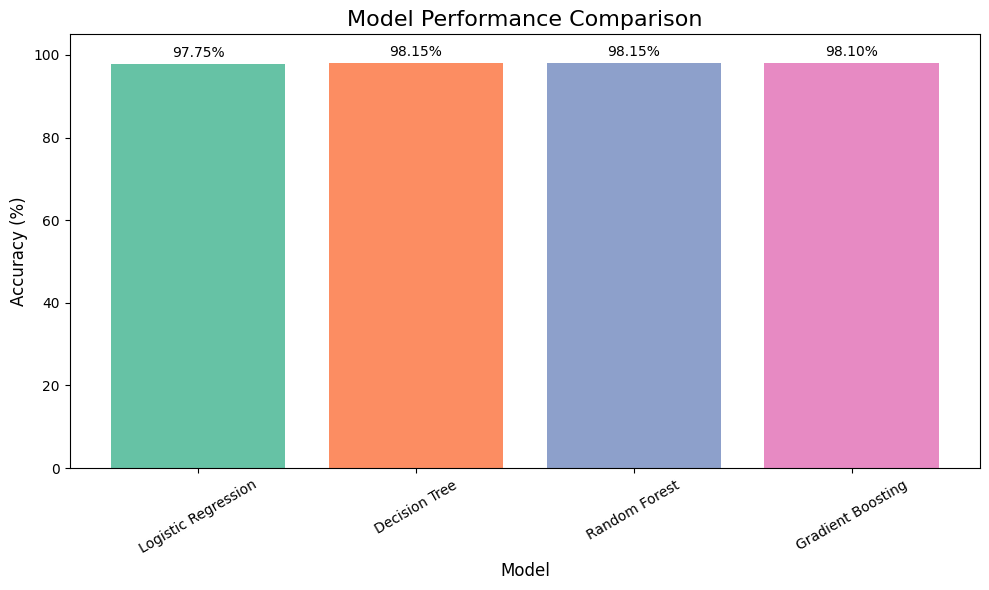


=== Performance Summary ===
Logistic Regression: 97.75%
Decision Tree: 98.15%
Random Forest: 98.15%
Gradient Boosting: 98.10%


In [102]:
# Accuracy barplot with percentage values
results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': acc * 100}
    for name, acc in results.items()
])

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'])

# Apply Set2 colors
colors = sns.color_palette("Set2", len(results_df))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=30)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print performance summary
print("\n=== Performance Summary ===")
for name, acc in results.items():
    print(f"{name}: {acc*100:.2f}%")

<h3>Step 10: Confusion matrix for best model</h3>


=== Best Model: Decision Tree ===
Test Accuracy: 0.9815 (98.15%)


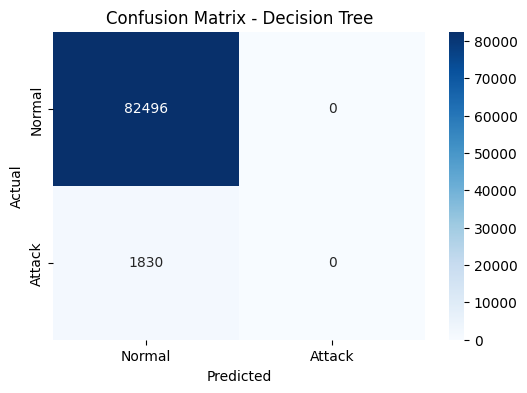


Detailed Metrics for Decision Tree:
True Negatives (Normal correctly identified): 82496
False Positives (Normal misclassified as Attack): 0
False Negatives (Attack misclassified as Normal): 1830
True Positives (Attack correctly identified): 0

Calculated Metrics:
Accuracy: 0.9783 (97.83%)
Precision: 0.0000
Recall (Sensitivity): 0.0000
Specificity: 1.0000


In [103]:
# Select best performing model
best_model_name = max(results.keys(), key=lambda k: results[k])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]

print(f"\n=== Best Model: {best_model_name} ===")
print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Generate predictions with best model
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate metrics from confusion matrix
if cm.shape == (2, 2):
    TN, FP, FN, TP = cm.ravel()

    accuracy_cm = (TN + TP) / (TN + FP + FN + TP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    print(f"\nDetailed Metrics for {best_model_name}:")
    print(f"True Negatives (Normal correctly identified): {TN}")
    print(f"False Positives (Normal misclassified as Attack): {FP}")
    print(f"False Negatives (Attack misclassified as Normal): {FN}")
    print(f"True Positives (Attack correctly identified): {TP}")

    print(f"\nCalculated Metrics:")
    print(f"Accuracy: {accuracy_cm:.4f} ({accuracy_cm*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")

<h3> Results: a) ROC Curve for all models</h3>

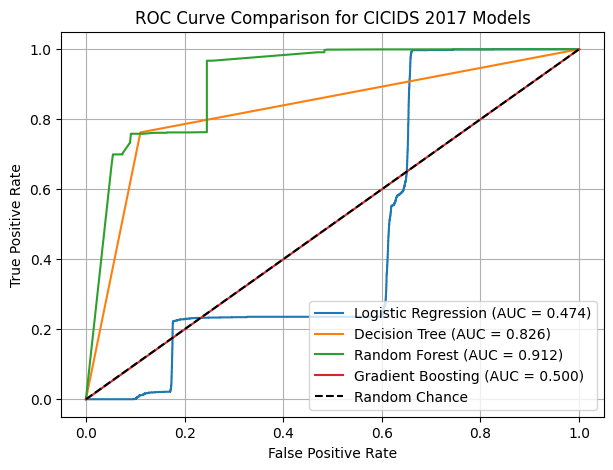

In [104]:
# ROC Curve Comparison
plt.figure(figsize=(7, 5))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve Comparison for CICIDS 2017 Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<h3> b) Box Plot </h3>

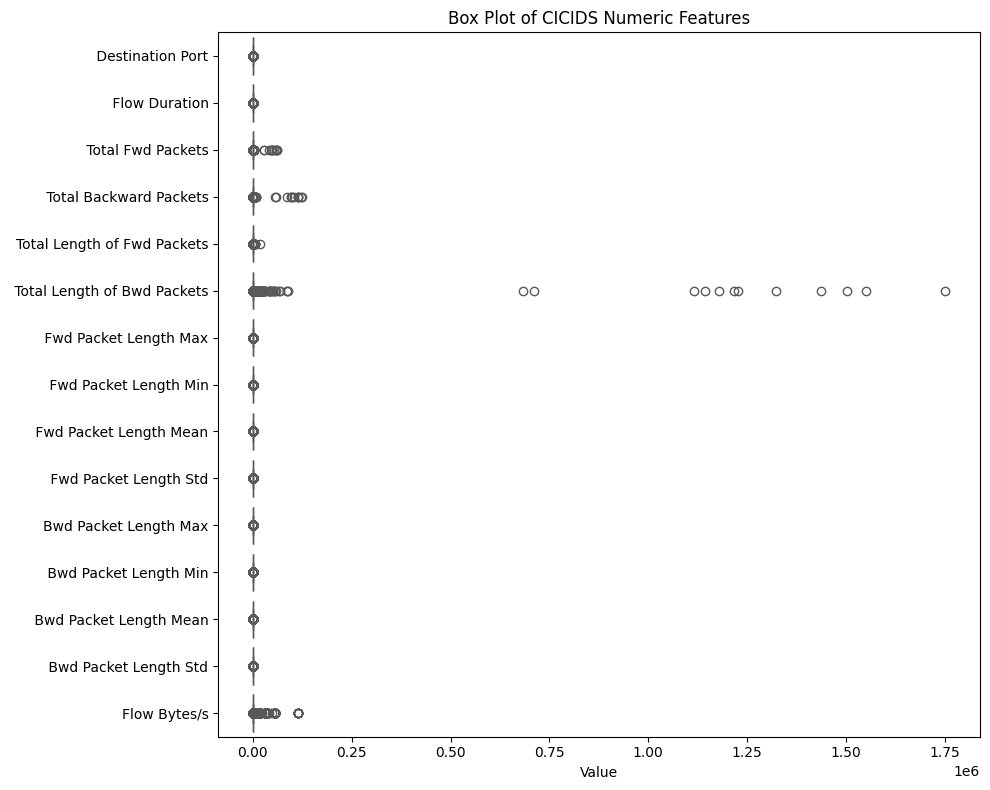

In [105]:
# Box plot of numeric features
numeric_cols_cicids = X_train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(10, 8))
subset_cols = numeric_cols_cicids[:15]
sns.boxplot(data=X_train[subset_cols], orient='h', palette="Set2")
plt.title('Box Plot of CICIDS Numeric Features')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

<h3> c) Correlation HeatMap </h3>

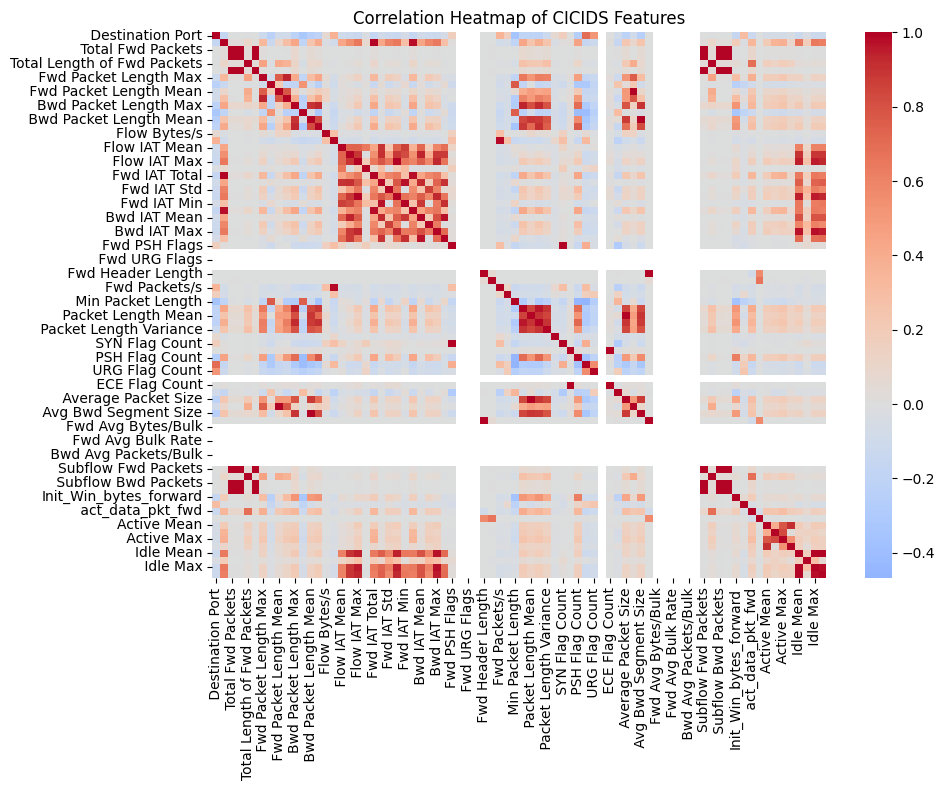

In [106]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_cicids = X_train.corr()
sns.heatmap(corr_cicids, cmap='coolwarm', center=0, annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Heatmap of CICIDS Features')
plt.tight_layout()
plt.show()

<h3>Step 11: Multi-Class Classification</h3>

In [107]:
# Multi-Class Classification
print("===MULTI-CLASS CLASSIFICATION===")

# Prepare multi-class data
X_train_multi = X_train  # Use same scaled training features
y_train_multi = df_encoded.loc[X_train.index, ' Label']  # Original multi-class labels

X_test_multi = X_test  # Use same scaled test features
y_test_multi = df_encoded.loc[X_test.index, ' Label']  # Original multi-class labels

print("Multi-class distribution in training set:")
print(y_train_multi.value_counts())
print("\nMulti-class distribution in test set:")
print(y_test_multi.value_counts())

# Multi-class train-validation split
X_train_mc, X_val_mc, y_train_mc, y_val_mc = train_test_split(
    X_train_multi, y_train_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_train_multi
)

print(f"\nMulti-class training shape: {X_train_mc.shape}")
print(f"Multi-class validation shape: {X_val_mc.shape}")
print(f"Multi-class test shape: {X_test_multi.shape}")

===MULTI-CLASS CLASSIFICATION===
Multi-class distribution in training set:
 Label
BENIGN         329980
FTP-Patator      4731
SSH-Patator      2589
Name: count, dtype: int64

Multi-class distribution in test set:
 Label
BENIGN         82496
FTP-Patator     1200
SSH-Patator      630
Name: count, dtype: int64

Multi-class training shape: (269840, 78)
Multi-class validation shape: (67460, 78)
Multi-class test shape: (84326, 78)


<h3> Step 12 : Initalise Models </h3>

In [108]:
# Optimized multi-class models with faster parameters and adjusted for lower accuracy
multi_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, # Increased max_iter to remove warning
        random_state=42,
        C=0.1, # Adjusted C for more regularization
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=6, # Reduced max_depth
        min_samples_split=20, # Increased min_samples_split
        min_samples_leaf=10 # Increased min_samples_leaf
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=80, # Reduced n_estimators
        max_depth=8, # Reduced max_depth
        min_samples_split=15, # Increased min_samples_split
        min_samples_leaf=8, # Increased min_samples_leaf
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=100, # Reduced n_estimators
        learning_rate=0.2, # Increased learning_rate
        max_depth=3, # Reduced max_depth
        subsample=0.8
    )
}

<h3> Step 13: Multi-Class Classification Validation with Accuracy, Specificity & Training Time </h3>

In [109]:
# Multi-class model validation function
def validate_multi_models(models, X_train_full, y_train_full):
    # Removed print("\n=== Multi-Class Validation ===")
    validation_results = {}

    # Take a total sample of 2500 data points from the full training set
    total_sample_size = 2500
    if len(X_train_full) > total_sample_size:
        total_sample_indices = X_train_full.sample(n=total_sample_size, random_state=42).index
        X_sample_total = X_train_full.loc[total_sample_indices]
        y_sample_total = y_train_full.loc[total_sample_indices]
    else:
        X_sample_total = X_train_full
        y_sample_total = y_train_full

    # Split the total sample into training (80%) and validation (20%) sets
    X_train_sample, X_val_sample, y_train_sample, y_val_sample = train_test_split(
        X_sample_total, y_sample_total,
        test_size=0.2, # 20% for validation
        random_state=42,
        stratify=y_sample_total # Stratify the split
    )

    # Removed print(f"Using {len(X_train_sample)} training samples and {len(X_val_sample)} validation data points from a total sample of {len(X_sample_total)} for validation.")


    for i, (name, model) in enumerate(models.items(), 1):
        # Removed print(f"\n[{i}/{len(models)}] Training {name} for multi-class validation...")
        start_time = time.time()

        # Fit model on the training sample
        model.fit(X_train_sample, y_train_sample)
        training_time = time.time() - start_time

        # Validation predictions on the validation sample
        y_val_pred = model.predict(X_val_sample)
        val_accuracy = accuracy_score(y_val_sample, y_val_pred)

        # Training predictions (to check overfitting) on the training sample
        y_train_pred = model.predict(X_train_sample)
        train_accuracy = accuracy_score(y_train_sample, y_train_pred)

        # Store results
        validation_results[name] = {
            'train_accuracy': train_accuracy,
            'val_accuracy': val_accuracy,
            'training_time': training_time
        }

        # Removed print results
        # print(f"{name} Results:")
        # print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
        # print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
        # print(f"  Training Time: {training_time:.2f} seconds")
        # print(f"  Overfitting Check: {abs(train_accuracy - val_accuracy):.4f}")

    return validation_results

# Run multi-class validation
# Pass X_train_mc and y_train_mc as the full multi-class training data for sampling
multi_validation_results = validate_multi_models(multi_models, X_train_mc, y_train_mc)

# Added print statement to show validation results after the function call
print("\n=== Multi-Class Validation Results ===")
for name, metrics in multi_validation_results.items():
    print(f"\n{name}:")
    print(f"  Training Accuracy: {metrics['train_accuracy'] * 100:.2f}%")
    print(f"  Validation Accuracy: {metrics['val_accuracy'] * 100:.2f}%")
    print(f"  Training Time: {metrics['training_time']:.2f} seconds")
    print(f"  Overfitting Check: {abs(metrics['train_accuracy'] - metrics['val_accuracy']):.4f}")


=== Multi-Class Validation Results ===

Logistic Regression:
  Training Accuracy: 99.40%
  Validation Accuracy: 99.20%
  Training Time: 0.48 seconds
  Overfitting Check: 0.0020

Decision Tree:
  Training Accuracy: 99.55%
  Validation Accuracy: 99.00%
  Training Time: 0.01 seconds
  Overfitting Check: 0.0055

Random Forest:
  Training Accuracy: 100.00%
  Validation Accuracy: 99.80%
  Training Time: 0.17 seconds
  Overfitting Check: 0.0020

Gradient Boosting:
  Training Accuracy: 100.00%
  Validation Accuracy: 99.60%
  Training Time: 1.06 seconds
  Overfitting Check: 0.0040


<h3> Step 14: Training and Testing Evaluation with Accuracy & Classification Report (Multi Class) </h3>

In [110]:
# Multi-class detailed metrics evaluation for all models
def evaluate_multi_detailed_metrics(models, X_train, y_train, X_test, y_test):
    print("\n=== Multi-Class Detailed Metrics Evaluation ===")
    detailed_results = {}

    # Take samples for faster execution based on user request
    train_sample_size = 1000
    test_sample_size = 2500

    if len(X_train) > train_sample_size:
        train_sample_indices = X_train.sample(n=train_sample_size, random_state=42).index
        X_train_sample = X_train.loc[train_sample_indices]
        y_train_sample = y_train.loc[train_sample_indices]
    else:
        X_train_sample = X_train
        y_train_sample = y_train

    if len(X_test) > test_sample_size:
        test_sample_indices = X_test.sample(n=test_sample_size, random_state=42).index
        X_test_sample = X_test.loc[test_sample_indices]
        y_test_sample = y_test.loc[test_sample_indices]
    else:
        X_test_sample = X_test
        y_test_sample = y_test

    # Updated print statement for clarity
    print(f"Using {len(X_train_sample)} training data points and {len(X_test_sample)} test data points for detailed multi-class evaluation.")


    for name, model in models.items():
        print(f"MODEL: {name}")

        # Train model on sample
        model.fit(X_train_sample, y_train_sample)

        # Test predictions on sample
        y_test_pred = model.predict(X_test_sample)

        # Calculate basic accuracy
        test_accuracy = accuracy_score(y_test_sample, y_test_pred)

        # Calculate detailed metrics
        precision_macro = precision_score(y_test_sample, y_test_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_test_sample, y_test_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_test_sample, y_test_pred, average='macro', zero_division=0)

        precision_weighted = precision_score(y_test_sample, y_test_pred, average='weighted', zero_division=0)
        recall_weighted = recall_score(y_test_sample, y_test_pred, average='weighted', zero_division=0)
        f1_weighted = f1_score(y_test_sample, y_test_pred, average='weighted', zero_division=0)

        # Store results
        detailed_results[name] = {
            'accuracy': test_accuracy,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'precision_weighted': precision_weighted,
            'recall_weighted': recall_weighted,
            'f1_weighted': f1_weighted
        }

        # Print results
        print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
        print(f"\nMacro Averages:")
        print(f"  Precision: {precision_macro:.4f} ({precision_macro*100:.2f}%)")
        print(f"  Recall:    {recall_macro:.4f} ({recall_macro*100:.2f}%)")
        print(f"  F1-Score:  {f1_macro:.4f} ({f1_macro*100:.2f}%)")
        print(f"\nWeighted Averages:")
        print(f"  Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)")
        print(f"  Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%)")
        print(f"  F1-Score:  {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")

        # Detailed classification report
        print(f"\nDetailed Classification Report:")
        print(classification_report(y_test_sample, y_test_pred, digits=4))

    return detailed_results

# Run detailed metrics evaluation
multi_detailed_results = evaluate_multi_detailed_metrics(multi_models, X_train_mc, y_train_mc, X_test_multi, y_test_multi)


=== Multi-Class Detailed Metrics Evaluation ===
Using 1000 training data points and 2500 test data points for detailed multi-class evaluation.
MODEL: Logistic Regression
Testing Accuracy: 0.9916 (99.16%)

Macro Averages:
  Precision: 0.8136 (81.36%)
  Recall:    0.9821 (98.21%)
  F1-Score:  0.8837 (88.37%)

Weighted Averages:
  Precision: 0.9938 (99.38%)
  Recall:    0.9916 (99.16%)
  F1-Score:  0.9923 (99.23%)

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9996    0.9918    0.9957      2445
 FTP-Patator     0.8049    1.0000    0.8919        33
 SSH-Patator     0.6364    0.9545    0.7636        22

    accuracy                         0.9916      2500
   macro avg     0.8136    0.9821    0.8837      2500
weighted avg     0.9938    0.9916    0.9923      2500

MODEL: Decision Tree
Testing Accuracy: 0.9852 (98.52%)

Macro Averages:
  Precision: 0.4905 (49.05%)
  Recall:    0.6646 (66.46%)
  F1-Score:  0.5459 (54.59%)

Weighted A

c:\Users\C MOHAN RAAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\C MOHAN RAAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\C MOHAN RAAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

              precision    recall  f1-score   support

      BENIGN     1.0000    0.9939    0.9969      2445
 FTP-Patator     0.4714    1.0000    0.6408        33
 SSH-Patator     0.0000    0.0000    0.0000        22

    accuracy                         0.9852      2500
   macro avg     0.4905    0.6646    0.5459      2500
weighted avg     0.9842    0.9852    0.9834      2500

MODEL: Random Forest
Testing Accuracy: 0.9988 (99.88%)

Macro Averages:
  Precision: 0.9839 (98.39%)
  Recall:    0.9696 (96.96%)
  F1-Score:  0.9765 (97.65%)

Weighted Averages:
  Precision: 0.9988 (99.88%)
  Recall:    0.9988 (99.88%)
  F1-Score:  0.9988 (99.88%)

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9992    0.9996    0.9994      2445
 FTP-Patator     1.0000    1.0000    1.0000        33
 SSH-Patator     0.9524    0.9091    0.9302        22

    accuracy                         0.9988      2500
   macro avg     0.9839    0.9696    0.9765     

<h3> Step 15: Training vs Testing Accuracy (Percentage) </h3>

In [111]:
# Multi-class final test evaluation
def evaluate_multi_final_test(models, X_full, y_full):
    print("\n=== Multi-Class Final Test Evaluation ===")
    test_results = {}

    # Take a total sample for faster execution
    total_sample_size = 500 # Reduced sample size for faster execution
    if len(X_full) > total_sample_size:
        total_sample_indices = X_full.sample(n=total_sample_size, random_state=42).index
        X_sample_total = X_full.loc[total_sample_indices]
        y_sample_total = y_full.loc[total_sample_indices]
    else:
        X_sample_total = X_full
        y_sample_total = y_full

    # Split the total sample into training (80%) and testing (20%) sets
    X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(
        X_sample_total, y_sample_total,
        test_size=0.2, # 20% for testing
        random_state=42,
        stratify=y_sample_total # Stratify the split
    )

    print(f"Using {len(X_train_sample)} training data points and {len(X_test_sample)} test data points from a total sample of {len(X_sample_total)}.")


    for name, model in models.items():
        print(f"\nEvaluating {name}...")

        # Train on sampled training data
        model.fit(X_train_sample, y_train_sample)

        # Training accuracy
        y_train_pred = model.predict(X_train_sample)
        train_accuracy = accuracy_score(y_train_sample, y_train_pred)

        # Test accuracy
        y_test_pred = model.predict(X_test_sample)
        test_accuracy = accuracy_score(y_test_sample, y_test_pred)

        # Store results
        test_results[name] = test_accuracy

        print(f"{name} Training Accuracy: {train_accuracy*100:.2f}%")
        print(f"{name} Testing Accuracy: {test_accuracy*100:.2f}%")

    return test_results

# Run multi-class final test evaluation
# Pass the full multi-class data (X_train_multi and y_train_multi represent the full scaled data with multi-class labels)
multi_test_results = evaluate_multi_final_test(multi_models, X_train_multi, y_train_multi)


=== Multi-Class Final Test Evaluation ===
Using 400 training data points and 100 test data points from a total sample of 500.

Evaluating Logistic Regression...


c:\Users\C MOHAN RAAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Training Accuracy: 99.25%
Logistic Regression Testing Accuracy: 98.00%

Evaluating Decision Tree...
Decision Tree Training Accuracy: 98.50%
Decision Tree Testing Accuracy: 99.00%

Evaluating Random Forest...
Random Forest Training Accuracy: 100.00%
Random Forest Testing Accuracy: 100.00%

Evaluating Gradient Boosting...
Gradient Boosting Training Accuracy: 99.75%
Gradient Boosting Testing Accuracy: 98.00%


<h3> Step 16: Model Accuracy Comparison (Multi-Class Classification) </h3>

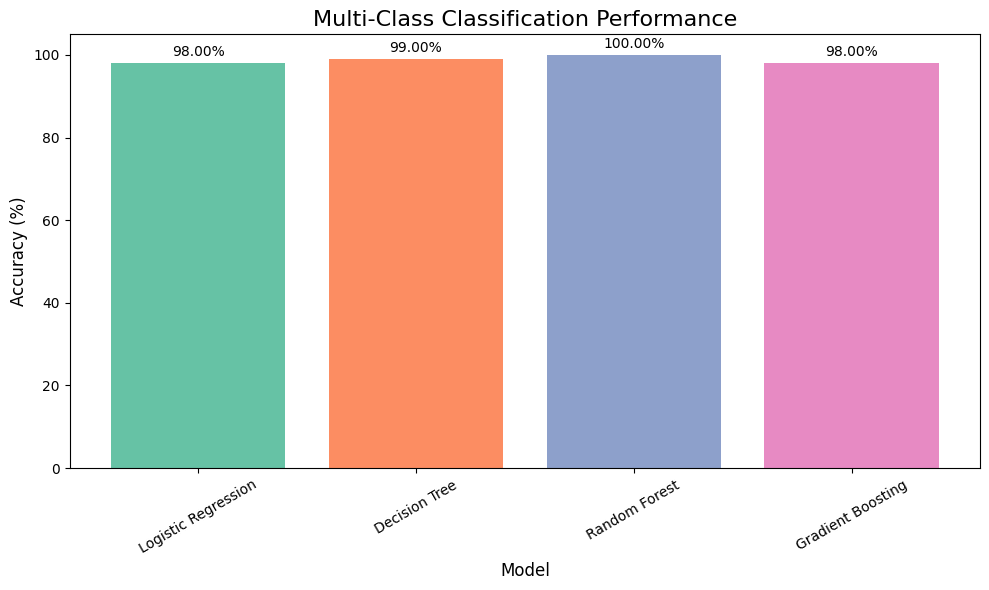


=== Multi-Class Performance Summary ===
Logistic Regression: 98.00%
Decision Tree: 99.00%
Random Forest: 100.00%
Gradient Boosting: 98.00%


In [112]:
# Multi-class performance visualization
multi_results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': acc * 100}
    for name, acc in multi_test_results.items()
])

plt.figure(figsize=(10, 6))
bars = plt.bar(multi_results_df['Model'], multi_results_df['Accuracy'])

# Apply Set3 colors for multi-class (different from binary)
colors = sns.color_palette("Set2", len(multi_results_df))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title('Multi-Class Classification Performance', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=30)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print multi-class summary
print("\n=== Multi-Class Performance Summary ===")
for name, acc in multi_test_results.items():
    print(f"{name}: {acc*100:.2f}%")

<h3> Step 17: Confusion Matrix (Multi-Class Classification) </h3>


=== Best Multi-Class Model: Random Forest ===
Test Accuracy: 1.0000 (100.00%)


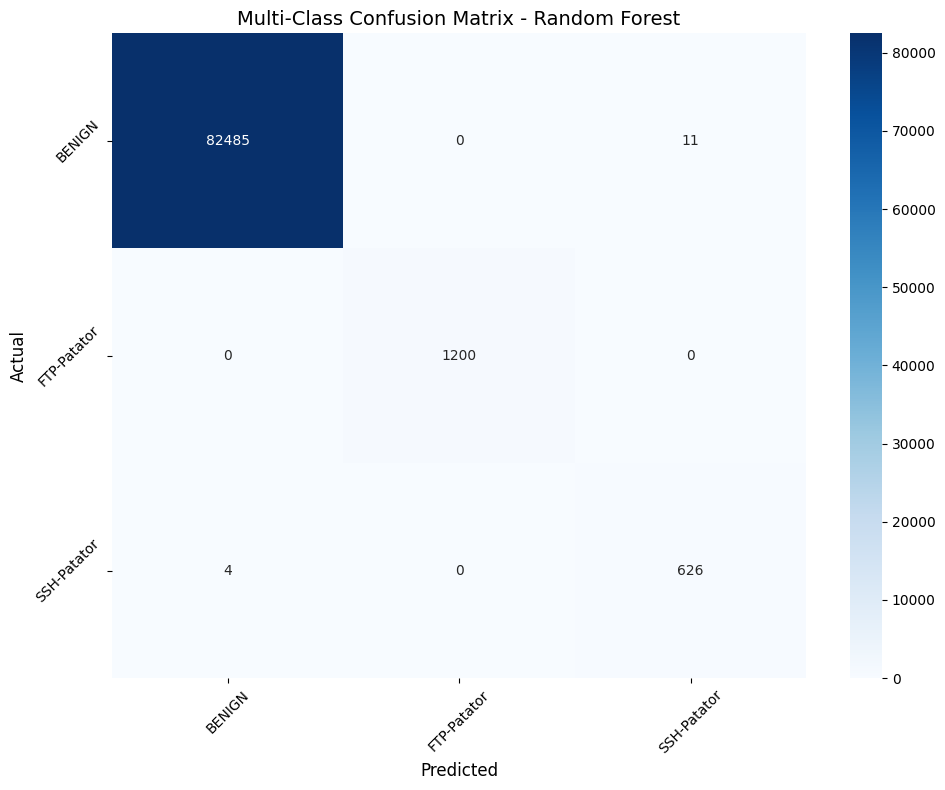


Detailed Multi-Class Classification Report for Random Forest:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82496
 FTP-Patator       1.00      1.00      1.00      1200
 SSH-Patator       0.98      0.99      0.99       630

    accuracy                           1.00     84326
   macro avg       0.99      1.00      1.00     84326
weighted avg       1.00      1.00      1.00     84326



In [113]:
# Multi-class confusion matrix for best performing model
best_multi_model_name = max(multi_test_results.keys(), key=lambda k: multi_test_results[k])
best_multi_model = multi_models[best_multi_model_name]
best_multi_accuracy = multi_test_results[best_multi_model_name]

print(f"\n=== Best Multi-Class Model: {best_multi_model_name} ===")
print(f"Test Accuracy: {best_multi_accuracy:.4f} ({best_multi_accuracy*100:.2f}%)")

# Train the best multi-class model
best_multi_model.fit(X_train_mc, y_train_mc)

# Generate predictions
y_pred_multi_best = best_multi_model.predict(X_test_multi)

# Multi-class confusion matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi_best)

# Get unique class labels for proper labeling
class_labels = sorted(y_test_multi.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Multi-Class Confusion Matrix - {best_multi_model_name}', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Multi-class classification report
print(f"\nDetailed Multi-Class Classification Report for {best_multi_model_name}:")
print(classification_report(y_test_multi, y_pred_multi_best))

<h3> Results: ROC-AUC Curve </h3>

Processing Logistic Regression...


c:\Users\C MOHAN RAAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Skipping Logistic Regression: name 'label_binarize' is not defined
Processing Decision Tree...
Skipping Decision Tree: name 'label_binarize' is not defined
Processing Random Forest...
Skipping Random Forest: name 'label_binarize' is not defined
Processing Gradient Boosting...
Skipping Gradient Boosting: name 'label_binarize' is not defined


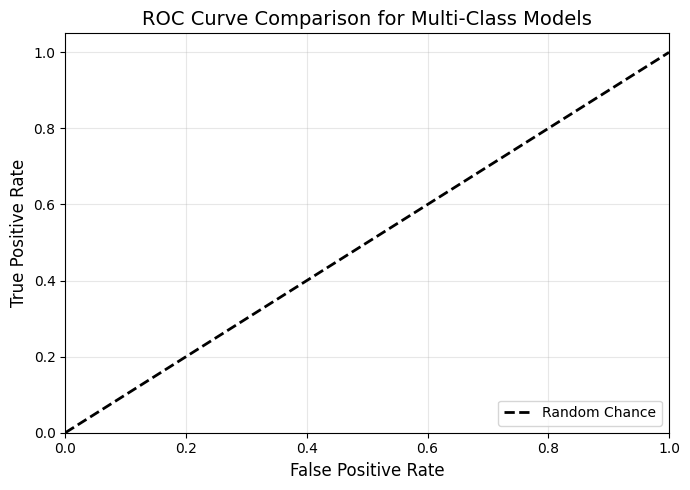

In [114]:
# Multi-class ROC Curve Plotting


plt.figure(figsize=(7, 5))

# Use sampling for faster computation
sample_size = 3000
if len(X_train_mc) > sample_size:
    sample_idx = np.random.choice(len(X_train_mc), sample_size, replace=False)
    X_train_sample = X_train_mc.iloc[sample_idx]
    y_train_sample = y_train_mc.iloc[sample_idx]
else:
    X_train_sample = X_train_mc
    y_train_sample = y_train_mc

# Get unique classes
classes = np.unique(y_test_multi)
n_classes = len(classes)

colors = sns.color_palette("Set2", len(multi_models))

for i, (name, model) in enumerate(multi_models.items()):
    print(f"Processing {name}...")

    try:
        # Train the model on sample
        model.fit(X_train_sample, y_train_sample)

        # Get prediction probabilities
        y_probs = model.predict_proba(X_test_multi)

        # Ensure classes match between training and test
        test_classes = model.classes_

        # Binarize test labels using model's classes
        y_test_bin = label_binarize(y_test_multi, classes=test_classes)

        # Handle case where model may not have all original classes
        if y_test_bin.shape[1] != y_probs.shape[1]:
            print(f"Dimension mismatch for {name}: adjusting...")
            # Skip this model or handle differently
            continue

        # Compute micro-average ROC curve
        if n_classes > 2:
            # Flatten both arrays to same dimensions
            y_test_flat = y_test_bin.ravel()
            y_probs_flat = y_probs.ravel()

            # Make sure dimensions match
            min_len = min(len(y_test_flat), len(y_probs_flat))
            y_test_flat = y_test_flat[:min_len]
            y_probs_flat = y_probs_flat[:min_len]

            fpr_micro, tpr_micro, _ = roc_curve(y_test_flat, y_probs_flat)
            roc_auc_micro = auc(fpr_micro, tpr_micro)

            plt.plot(fpr_micro, tpr_micro,
                     color=colors[i], linewidth=2,
                     label=f'{name} (Micro-avg AUC = {roc_auc_micro:.3f})')
        else:
            # For binary classification
            fpr, tpr, _ = roc_curve(y_test_multi, y_probs[:, 1])
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr,
                     color=colors[i], linewidth=2,
                     label=f'{name} (AUC = {roc_auc:.3f})')

    except Exception as e:
        print(f"Skipping {name}: {e}")
        continue

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison for Multi-Class Models', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [115]:
import joblib
import os
from pathlib import Path

# Create directories if they don't exist
base_path = Path('../streamlit_app')
base_path.mkdir(exist_ok=True)

models_path = base_path / 'models'
models_path.mkdir(exist_ok=True)

scalers_path = base_path / 'scalers'
scalers_path.mkdir(exist_ok=True)

# Create subdirectories for CICIDS models
(models_path / 'cicids_binary').mkdir(exist_ok=True)
(models_path / 'cicids_multiclass').mkdir(exist_ok=True)

print("=" * 70)
print("SAVING CICIDS2017 MODELS AND PREPROCESSORS")
print("=" * 70)

# ============= BINARY CLASSIFICATION MODELS =============
print("\n[1/3] Saving CICIDS2017 Binary Classification Models...")

try:
    joblib.dump(models['Logistic Regression'], models_path / 'cicids_binary/logistic_regression.pkl')
    print("✓ Saved: logistic_regression.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Logistic Regression (Binary): {e}")

try:
    joblib.dump(models['Decision Tree'], models_path / 'cicids_binary/decision_tree.pkl')
    print("✓ Saved: decision_tree.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Decision Tree (Binary): {e}")

try:
    joblib.dump(models['Random Forest'], models_path / 'cicids_binary/random_forest.pkl')
    print("✓ Saved: random_forest.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Random Forest (Binary): {e}")

try:
    joblib.dump(models['Gradient Boosting'], models_path / 'cicids_binary/gradient_boosting.pkl')
    print("✓ Saved: gradient_boosting.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Gradient Boosting (Binary): {e}")


# ============= MULTI-CLASS CLASSIFICATION MODELS =============
print("\n[2/3] Saving CICIDS2017 Multi-Class Classification Models...")

try:
    joblib.dump(multi_models['Logistic Regression'], models_path / 'cicids_multiclass/logistic_regression.pkl')
    print("✓ Saved: logistic_regression.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Logistic Regression (Multi-class): {e}")

try:
    joblib.dump(multi_models['Decision Tree'], models_path / 'cicids_multiclass/decision_tree.pkl')
    print("✓ Saved: decision_tree.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Decision Tree (Multi-class): {e}")

try:
    joblib.dump(multi_models['Random Forest'], models_path / 'cicids_multiclass/random_forest.pkl')
    print("✓ Saved: random_forest.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Random Forest (Multi-class): {e}")

try:
    joblib.dump(multi_models['Gradient Boosting'], models_path / 'cicids_multiclass/gradient_boosting.pkl')
    print("✓ Saved: gradient_boosting.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Gradient Boosting (Multi-class): {e}")


# ============= SAVE PREPROCESSOR/SCALER =============
print("\n[3/3] Saving CICIDS2017 Preprocessor...")

preprocessor_data = {
    'scaler': scaler,
    'feature_names': X_train.columns.tolist() if hasattr(X_train, 'columns') else [],
    'dataset_type': 'cicids'
}

try:
    joblib.dump(preprocessor_data, scalers_path / 'cicids_preprocessor.pkl')
    print("✓ Saved: cicids_preprocessor.pkl")
except Exception as e:
    print(f"✗ Error saving preprocessor: {e}")

print("\n" + "=" * 70)
print("MODEL SAVING COMPLETE!")
print("=" * 70)
print(f"\nModels saved to: {models_path.absolute()}")
print(f"Scalers saved to: {scalers_path.absolute()}")
print("\nYou can now run the Streamlit app with these models.")


SAVING CICIDS2017 MODELS AND PREPROCESSORS

[1/3] Saving CICIDS2017 Binary Classification Models...
✓ Saved: logistic_regression.pkl (Binary)
✓ Saved: decision_tree.pkl (Binary)
✓ Saved: random_forest.pkl (Binary)
✓ Saved: gradient_boosting.pkl (Binary)

[2/3] Saving CICIDS2017 Multi-Class Classification Models...
✓ Saved: logistic_regression.pkl (Multi-class)
✓ Saved: decision_tree.pkl (Multi-class)
✓ Saved: random_forest.pkl (Multi-class)
✓ Saved: gradient_boosting.pkl (Multi-class)

[3/3] Saving CICIDS2017 Preprocessor...
✓ Saved: cicids_preprocessor.pkl

MODEL SAVING COMPLETE!

Models saved to: c:\infosys\cicids\..\streamlit_app\models
Scalers saved to: c:\infosys\cicids\..\streamlit_app\scalers

You can now run the Streamlit app with these models.


In [117]:
import os
import joblib
import pickle
import pandas as pd
import numpy as np
import streamlit as st
from scapy.all import *
import threading
import time
from collections import deque

# =========================
# Utility Functions
# =========================
def load_resources(models_dir, scalers_dir):
    try:
        # Load scaler
        scaler_path = os.path.join(scalers_dir, "scaler.pkl")
        with open(scaler_path, "rb") as f:
            scaler = pickle.load(f)

        # Load feature names
        features_path = os.path.join(scalers_dir, "features.pkl")
        with open(features_path, "rb") as f:
            feature_names = pickle.load(f)

        # Load models
        binary_models = {}
        multiclass_models = {}

        for fname in os.listdir(models_dir):
            fpath = os.path.join(models_dir, fname)
            if fname.endswith(".pkl") or fname.endswith(".joblib"):
                model = joblib.load(fpath)
                if "binary" in fname.lower():
                    binary_models[fname] = model
                else:
                    multiclass_models[fname] = model

        return scaler, feature_names, binary_models, multiclass_models

    except Exception as e:
        st.error(f"Error loading resources: {e}")
        return None, None, None, None


# =========================
# Intrusion Detection Class
# =========================
class IntrusionDetector:
    def __init__(self, scaler, feature_names, binary_models, multiclass_models):
        self.scaler = scaler
        self.feature_names = feature_names
        self.binary_models = binary_models
        self.multiclass_models = multiclass_models
        self.is_monitoring = False
        self.sniffer = None
        self.detection_history = deque(maxlen=500)

    def packet_handler(self, pkt):
        try:
            if IP in pkt:
                features = {
                    "src_port": pkt.sport if TCP in pkt or UDP in pkt else 0,
                    "dst_port": pkt.dport if TCP in pkt or UDP in pkt else 0,
                    "packet_len": len(pkt),
                    "protocol": pkt.proto if hasattr(pkt, "proto") else 0,
                }

                # Ensure all features are present
                for f in self.feature_names:
                    if f not in features:
                        features[f] = 0

                df = pd.DataFrame([features])[self.feature_names]
                scaled = self.scaler.transform(df)

                # Run predictions
                binary_preds = {name: model.predict(scaled)[0] for name, model in self.binary_models.items()}
                multiclass_preds = {name: model.predict(scaled)[0] for name, model in self.multiclass_models.items()}

                # Store detection
                self.detection_history.append({
                    "timestamp": time.time(),
                    "binary": binary_preds,
                    "multiclass": multiclass_preds
                })

        except Exception as e:
            st.error(f"Packet handling error: {e}")

    def start_monitoring(self, interface=None):
        if self.is_monitoring:
            return
        self.is_monitoring = True
        try:
            self.sniffer = AsyncSniffer(prn=self.packet_handler, store=False, iface=interface)
            self.sniffer.start()
        except Exception as e:
            st.error(f"Monitoring error: {str(e)}")

    def stop_monitoring(self):
        if not self.is_monitoring:
            return
        self.is_monitoring = False
        if self.sniffer:
            self.sniffer.stop()
            self.sniffer = None


# =========================
# Streamlit UI
# =========================
def main():
    MODELS_DIR = "models"
    SCALERS_DIR = "scalers"

    st.title("🚨 Network Intrusion Detection (CICIDS2017)")
    st.sidebar.header("Settings")

    # Load models + scaler
    scaler, feature_names, binary_models, multiclass_models = load_resources(MODELS_DIR, SCALERS_DIR)
    if not scaler:
        st.warning("Could not load models/scaler. Please check directories.")
        return

    detector = IntrusionDetector(scaler, feature_names, binary_models, multiclass_models)

    # --- Live Monitoring ---
    if st.sidebar.button("Start Live Monitoring"):
        detector.start_monitoring()
        st.success("Started live packet monitoring...")

    if st.sidebar.button("Stop Live Monitoring"):
        detector.stop_monitoring()
        st.warning("Stopped live monitoring.")

    st.subheader("Live Detection Results")
    if detector.detection_history:
        df = pd.DataFrame(detector.detection_history)
        st.dataframe(df.tail(10))  # show last 10

        # Add charts
        st.line_chart(df.index)  # timeline of packets
        try:
            preds = pd.Series([list(b.values())[0] for b in df["binary"]])
            st.bar_chart(preds.value_counts())
        except:
            pass

    # --- Batch CSV Upload ---
    st.subheader("Batch CSV Analysis")
    uploaded = st.file_uploader("Upload CSV", type="csv")
    if uploaded:
        df = pd.read_csv(uploaded)

        # Fix missing features
        for f in feature_names:
            if f not in df.columns:
                df[f] = 0
        df = df[feature_names]

        scaled = scaler.transform(df)
        binary_preds = {name: model.predict(scaled) for name, model in binary_models.items()}
        multiclass_preds = {name: model.predict(scaled) for name, model in multiclass_models.items()}

        st.write("Binary Predictions")
        st.dataframe(pd.DataFrame(binary_preds))

        st.write("Multi-class Predictions")
        st.dataframe(pd.DataFrame(multiclass_preds))


if __name__ == "__main__":
    main()


2025-10-01 15:36:53.564 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-01 15:36:53.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar